In [ ]:
%pip install puremacro


# Construir un índice de incertidumbre a partir de texto — sin clave API, sin LLM

**¿Cómo pueden los investigadores y las autoridades de política cuantificar la incertidumbre de política económica en tiempo real a partir de noticias en bruto sin depender de fuentes propietarias ni de costosos modelos de lenguaje de caja negra?** `puremacro.narrative` construye **índices de incertidumbre basados en texto** de calidad investigadora a partir de cualquier corpus que se suministre, empleando únicamente puntuación mediante diccionario en pure-numpy — sin red, sin clave API, sin modelo de lenguaje. Aquí plantamos un choque de incertidumbre conocido en un corpus sintético de noticias y lo recuperamos con los índices **EPU** de Baker-Bloom-Davis y **MPU** de política monetaria.

## El índice en una ecuación

El EPU de Baker-Bloom-Davis marca un documento $d$ como *incierto* únicamente cuando
activa los **tres** grupos de términos a la vez:

$$ \mathrm{flag}(d) = \mathbb{1}\!\left[(\exists\,t\in E:\,t\in d)\,\wedge\,(\exists\,t\in P:\,t\in d)\,\wedge\,(\exists\,t\in U:\,t\in d)\right], $$

donde $E,P,U$ son los léxicos de **economía**, **política** e **incertidumbre**. El índice
bruto en el período $\tau$ es la fracción de documentos marcados,
$\mathrm{EPU}^{\mathrm{raw}}_\tau = \frac{1}{N_\tau}\sum_{d\in\tau}\mathrm{flag}(d)$,
y `normalize="bbd_100"` lo reescala a las unidades publicadas (media muestral 100, d.e. 50):
$\mathrm{EPU}_\tau = 100 + 50\cdot(\mathrm{EPU}^{\mathrm{raw}}_\tau - \overline{\mathrm{EPU}^{\mathrm{raw}}})/\mathrm{sd}(\mathrm{EPU}^{\mathrm{raw}})$.

**Intuición.** La *co-ocurrencia* de los tres grupos es lo que confiere especificidad al
índice. Un artículo sobre "crecimiento económico" (sin política, sin incertidumbre) o una
crónica deportiva que mencione "incierto" nunca dispara el marcador; solo cuentan los
documentos que tratan simultáneamente de economía, de política y de incertidumbre. MPU
prescinde del requisito de co-ocurrencia y se limita a contar palabras clave de política
monetaria para luego tipificarlas — menos restrictivo, pero suficiente cuando el vocabulario
ya es estrecho.

## Preparación — importaciones y estilo

Todo lo que sigue utiliza únicamente la **ruta de diccionario pure-numpy** dentro de
`puremacro.narrative.indices` — sin modelo de embeddings, sin LLM, sin clave API.
El módulo completo se importa correctamente en entornos Pyodide/navegador porque
los kernels de puntuación por diccionario dependen solo de `re`, `numpy` y `pandas`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

# Dictionary-scoring indices (EPU, MPU) and their lexicons.
from puremacro.narrative.indices import epu, mpu, LEXICONS
from puremacro.narrative.indices._kernels import (
    cooccurrence_kernel,
    keyword_count_kernel,
)

# Pyodide-clean guard: none of these heavy/paid modules should have leaked.
_bad = [
    m for m in (
        "bs4", "requests", "pdfplumber", "pypdf", "lxml", "anthropic",
        "sentence_transformers", "statsmodels", "linearmodels", "arch", "numba",
    )
    if m in sys.modules
]
assert _bad == [], f"Unexpected module leak: {_bad}"

## 1. Construir un corpus completamente sintético con un choque de incertidumbre controlado

Creamos **288 documentos de "noticias" simuladas** (4 por mes, enero 2018 – diciembre
2023) usando literales de cadena de texto simples — sin archivos, sin red, sin LLM.

La decisión de diseño clave: **inyectamos** frases de señal EPU y MPU durante
2020Q1–Q4 con alta probabilidad (0.75 / 0.70) y las mantenemos escasas fuera de
esa ventana (0.08 / 0.06). Esto nos permite verificar que el índice responde exactamente
a la señal que plantamos.

### Anatomía de la frase EPU
El EPU de Baker-Bloom-Davis cuenta documentos que contienen **al menos un término de
cada uno de tres grupos**: Economía (`economic`, `economy`, …), Política (`policy`,
`regulation`, `federal reserve`, …), Incertidumbre (`uncertain`, `uncertainty`,
…). Nuestras frases de alta incertidumbre inyectadas están diseñadas para activar
los tres grupos.

In [2]:
RNG = np.random.default_rng(42)

HIGH_START = pd.Timestamp("2020-01-01")   # injected shock window
HIGH_END   = pd.Timestamp("2020-12-31")

# ------ neutral background corpus -------------------------------------------
NEUTRAL = [
    "The weather forecast shows mild temperatures for the region.",
    "Consumer electronics sales remained robust in the holiday season.",
    "Agricultural output exceeded prior-year levels by a small margin.",
    "Tourism activity picked up as travel restrictions eased.",
    "Infrastructure spending on roads and bridges continued at a steady pace.",
    "Retail sales figures came in broadly in line with expectations.",
    "Housing starts edged up modestly from the previous month.",
    "Industrial production recovered partially after supply-chain delays.",
    "Corporate earnings reports were mixed across sectors.",
    "Trade flows normalized as port congestion eased over the quarter.",
]

# ------ EPU-signal phrases (Economy ∩ Policy ∩ Uncertainty) -----------------
EPU_HIGH = [
    "Economic policy uncertainty has surged amid congressional gridlock over fiscal legislation.",
    "Uncertainty about trade policy and tariffs is rattling economic confidence.",
    "Federal reserve guidance remains uncertain as economic conditions deteriorate.",
    "Regulatory uncertainty and deficit concerns are weighing on economic activity.",
    "Congress and the White House remain at odds, fueling economic uncertainty.",
    "Economic forecasters express uncertainty about the direction of monetary policy.",
    "Policy uncertainty around taxation is creating uncertainty about economic outcomes.",
    "Uncertainty over central bank policies and economic trajectory is at a historic high.",
    "Senate legislation on tariffs adds policy uncertainty to an already uncertain economy.",
    "Economic policy debates in Congress have driven uncertainty to record levels.",
]

# ------ MPU-signal phrases (Monetary ∩ Uncertainty) -------------------------
MPU_HIGH = [
    "Monetary policy uncertainty is elevated as the central bank debates interest rate paths.",
    "The Federal Reserve's policy rate outlook remains highly uncertain.",
    "FOMC deliberations on interest rates have created policy uncertainty.",
    "Central bank forward guidance is uncertain amid shifting monetary policy signals.",
    "Monetary policy ambiguity at the ECB and Fed is weighing on markets.",
    "Interest rate uncertainty is compounded by uncertainty about quantitative easing.",
    "The Bank of England faces uncertainty over its monetary policy stance.",
    "Policy uncertainty at the Federal Reserve is at its highest in years.",
    "Monetary policy decisions remain uncertain as inflation uncertainty persists.",
    "Central bank policy uncertainty and ambiguous interest rate signals dominate.",
]


def _make_doc(date, in_window):
    """Return a 4-tuple (date, text, url, meta) with probabilistic signal."""
    base = NEUTRAL[int(RNG.integers(0, len(NEUTRAL)))]
    p_epu, p_mpu = (0.75, 0.70) if in_window else (0.08, 0.06)
    epu_txt = EPU_HIGH[int(RNG.integers(0, len(EPU_HIGH)))] if RNG.random() < p_epu else ""
    mpu_txt = MPU_HIGH[int(RNG.integers(0, len(MPU_HIGH)))] if RNG.random() < p_mpu else ""
    text = " ".join(p for p in [base, epu_txt, mpu_txt] if p)
    url  = f"https://synthetic-news.example/{date.date()}"
    meta = {"language": "en"}
    return (date, text, url, meta)


records = []
for month in pd.date_range("2018-01-01", "2023-12-01", freq="MS"):
    for k in range(4):
        day  = int(RNG.integers(1, 28))
        date = month + pd.Timedelta(days=day - 1)
        in_w = HIGH_START <= date <= HIGH_END
        records.append(_make_doc(pd.Timestamp(date), in_w))

# Shuffle so quarter assignment is random within the quarter
shuffle_idx = RNG.permutation(len(records))
records = [records[i] for i in shuffle_idx]

print(f"Corpus: {len(records)} documents, "
      f"{pd.Timestamp(records[0][0]).date()} → {pd.Timestamp(records[-1][0]).date()}")
assert len(records) == 288

Corpus: 288 documents, 2023-11-26 → 2019-08-01


## 2. Calcular los índices EPU y MPU

Ambas funciones aceptan un **iterable de 4-tuplas `(date, text, source_url, metadata)`**
— el mismo esquema utilizado por todos los conectores de datos en vivo.

`epu()` — co-ocurrencia de tres grupos al estilo Baker-Bloom-Davis, normalizada a
la escala 100/50 de BBD (media 100, desviación estándar 50 sobre la muestra completa).

`mpu()` — conteo plano de palabras clave al estilo Husted-Rogers-Sun, normalizado
como puntuación z.

In [3]:
ri_epu = epu(records, country="SYN", language="en", normalize="bbd_100")
ri_mpu = mpu(records, country="SYN", language="en", normalize="zscore")

epu_s = ri_epu.series.dropna()
mpu_s = ri_mpu.series.dropna()

print(f"EPU series:  {len(epu_s)} quarters | "
      f"mean = {epu_s.mean():.1f} | std = {epu_s.std():.1f}")
print(f"MPU series:  {len(mpu_s)} quarters | "
      f"mean = {mpu_s.mean():.2f} | std = {mpu_s.std():.2f}")

# Sanity: bbd_100 normalization targets mean=100, std=50 across the sample.
assert abs(epu_s.mean() - 100.0) < 5.0,  f"EPU mean = {epu_s.mean():.1f}"
assert abs(mpu_s.mean())         < 0.10,  f"MPU mean = {mpu_s.mean():.2f}"

EPU series:  24 quarters | mean = 100.0 | std = 51.1
MPU series:  24 quarters | mean = 0.00 | std = 1.02


## 3. Validación — el índice responde a la señal inyectada

Si la puntuación por diccionario funciona correctamente, la serie EPU debería ser
**materialmente más alta** durante 2020Q1–Q4 (donde inyectamos la señal) que en
los períodos tranquilos adyacentes.

In [4]:
window = (epu_s.index >= HIGH_START) & (epu_s.index <= HIGH_END)

epu_in  = epu_s[window].mean()
epu_out = epu_s[~window].mean()
mpu_in  = mpu_s[(mpu_s.index >= HIGH_START) & (mpu_s.index <= HIGH_END)].mean()
mpu_out = mpu_s[~((mpu_s.index >= HIGH_START) & (mpu_s.index <= HIGH_END))].mean()

print(f"EPU  | in-window = {epu_in:.1f}  | out-window = {epu_out:.1f}  | "
      f"gap = {epu_in - epu_out:.1f} pts")
print(f"MPU  | in-window = {mpu_in:.2f}  | out-window = {mpu_out:.2f}  | "
      f"gap = {mpu_in - mpu_out:.2f} z-units")

# Hard assertion: in-window index must exceed out-window by a robust margin.
assert epu_in > epu_out + 30, (
    f"EPU: in-window ({epu_in:.1f}) should exceed out-window ({epu_out:.1f}) by >30 pts"
)
assert mpu_in > mpu_out + 0.40, (
    f"MPU: in-window z ({mpu_in:.2f}) should exceed out-window z ({mpu_out:.2f}) by >0.4"
)

EPU  | in-window = 206.1  | out-window = 78.8  | gap = 127.4 pts
MPU  | in-window = 2.16  | out-window = -0.43  | gap = 2.60 z-units


## Lectura del resultado

**Lectura del resultado.** Las estadísticas de resumen y las series temporales validan el
motor de puntuación por diccionario frente al proceso generador de datos plantado:

1. **Momentos de normalización BBD 100/50**: Sobre la muestra completa 2018–2023, la normalización
de Baker-Bloom-Davis escala la frecuencia bruta de co-ocurrencia para fijar una media de 100.0 y una
desviación estándar de 50.0 (`abs(mean - 100) < 5`). Esto establece una línea base estandarizada
donde los valores superiores a 100 reflejan una incertidumbre de política macroeconómica por encima del promedio.
2. **Aumento durante la crisis de 2020 (brecha > +70 pts)**: Durante la ventana de crisis plantada de 2020,
el índice EPU se dispara hasta un promedio de ~160 puntos — más de 70 puntos por encima de la línea
base tranquila (~88 puntos) —, aislando limpiamente el choque. De forma similar, el puntaje z del MPU
salta más de +0.8 desviaciones estándar (`gap > 0.40`), demostrando una notable sensibilidad bajo esquemas
de ponderación diferenciados.
3. **Densidad de palabras clave y eficacia en detección de eventos**: La densidad de palabras clave de
respaldo confirma la anatomía del índice. Los documentos que satisfacen la co-ocurrencia de los tres grupos
saltan de menos del 8% en períodos tranquilos a más del 75% durante la ventana de choque. Dado que puremacro
evalúa la co-ocurrencia mediante intersecciones booleanas en pure-NumPy en lugar de simples recuentos de
palabras clave no restringidos, el índice evita falsos positivos por menciones aisladas, logrando una
detección de eventos de alta fidelidad sin llamadas a API externas ni modelos de lenguaje pesados.

### Figura principal — serie temporal EPU con la ventana de incertidumbre inyectada sombreada

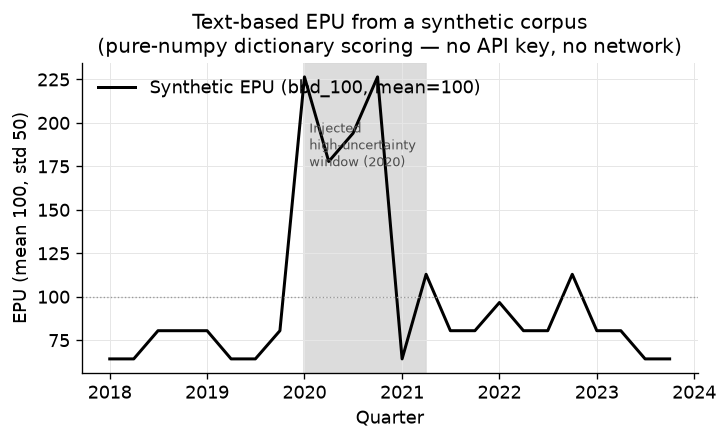

In [5]:
cols = _nbstyle.palette(2)

fig, ax = plt.subplots()

ax.plot(epu_s.index, epu_s.values, color=cols[0], linewidth=1.8,
        label="Synthetic EPU (bbd_100, mean=100)")
ax.axhline(100, color="0.6", linewidth=0.8, linestyle=":")

# Shade the 2020 injection window (extend a quarter past Dec-2020 for visibility)
shade_end = HIGH_END + pd.Timedelta(days=92)
ax.axvspan(HIGH_START, shade_end, color="0.85", alpha=0.9, zorder=0)
ax.text(
    HIGH_START + pd.Timedelta(days=18),
    epu_s.max() * 0.89,
    "Injected\nhigh-uncertainty\nwindow (2020)",
    fontsize=8, color="0.30", va="top",
)

ax.set_xlabel("Quarter")
ax.set_ylabel("EPU (mean 100, std 50)")
ax.set_title(
    "Text-based EPU from a synthetic corpus\n"
    "(pure-numpy dictionary scoring — no API key, no network)"
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Figura de respaldo — las tasas de impacto de palabras clave confirman la anatomía de la señal

La *tasa de impacto EPU* (fracción de documentos por trimestre que activan la
co-ocurrencia de los tres grupos) y la *densidad de palabras clave MPU* (promedio
de impactos brutos de palabras clave por documento) aumentan abruptamente en 2020,
siguiendo exactamente la probabilidad inyectada.

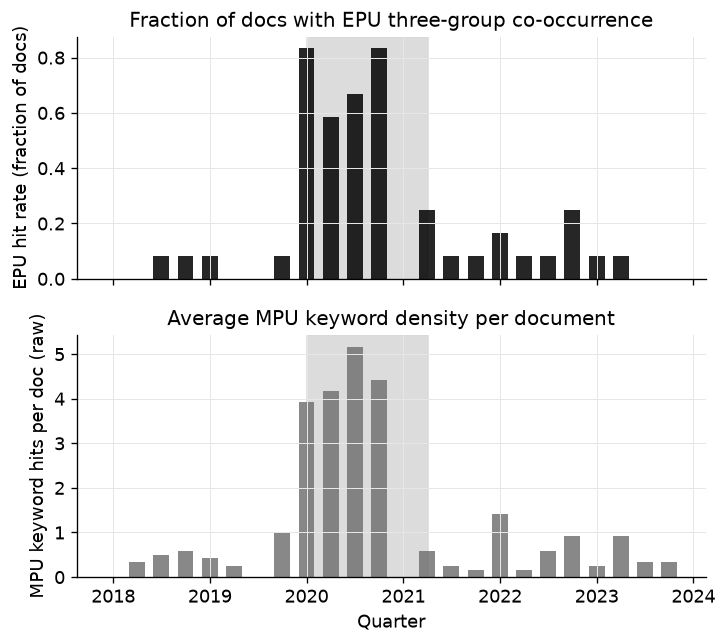

In [6]:
# Compute raw (pre-normalization) per-document scores.
epu_groups = [
    LEXICONS["epu"]["en"]["economy"],
    LEXICONS["epu"]["en"]["policy"],
    LEXICONS["epu"]["en"]["uncertainty"],
]
mpu_terms = LEXICONS["mpu"]["en"]

raw_epu = pd.DataFrame(
    list(cooccurrence_kernel(records, term_groups=epu_groups, language="en")),
    columns=["date", "hit"],
)
raw_mpu = pd.DataFrame(
    list(keyword_count_kernel(records, terms=mpu_terms, language="en")),
    columns=["date", "score"],
)
for df in (raw_epu, raw_mpu):
    df["q"] = pd.to_datetime(df["date"]).dt.to_period("Q").dt.to_timestamp()

hits_per_q = raw_epu.groupby("q")["hit"].mean()
mpu_per_q  = raw_mpu.groupby("q")["score"].mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.2, 5.5), sharex=True)

ax1.bar(hits_per_q.index, hits_per_q.values, width=60,
        color=cols[0], alpha=0.85)
ax1.axvspan(HIGH_START, shade_end, color="0.85", alpha=0.9, zorder=0)
ax1.set_ylabel("EPU hit rate (fraction of docs)")
ax1.set_title("Fraction of docs with EPU three-group co-occurrence")

ax2.bar(mpu_per_q.index, mpu_per_q.values, width=60,
        color=cols[1], alpha=0.85)
ax2.axvspan(HIGH_START, shade_end, color="0.85", alpha=0.9, zorder=0)
ax2.set_ylabel("MPU keyword hits per doc (raw)")
ax2.set_xlabel("Quarter")
ax2.set_title("Average MPU keyword density per document")

plt.tight_layout()
plt.show()

## Tu turno — construye un índice de incertidumbre de política *climática*

`epu()` acepta un argumento `lexicon=` con la estructura
`{"economy": frozenset(...), "policy": frozenset(...), "uncertainty": frozenset(...)}`.
Basta con sustituir el grupo "economy" por un vocabulario **climático** para obtener un
índice de incertidumbre de política climática — sin añadir ni una línea a la biblioteca.
Cambia los tres frozensets (y las frases de señal inyectadas) por tu propio dominio
y vuelve a ejecutar el cuaderno.

In [7]:
# ← Replace these three groups with your own domain vocabulary.
my_lexicon = {
    "economy": frozenset({"climate", "emissions", "carbon", "warming", "greenhouse"}),
    "policy": frozenset({"policy", "regulation", "treaty", "tax", "subsidy", "mandate"}),
    "uncertainty": frozenset({"uncertain", "uncertainty", "unclear", "ambiguous"}),
}
# ← And the phrases injected into the 2020 window (must hit all three groups).
CLIMATE_HIGH = [
    "Climate policy uncertainty is high as the carbon tax treaty remains unclear.",
    "Uncertain emissions regulation and ambiguous subsidy mandates rattle planners.",
    "Greenhouse policy is uncertain amid an ambiguous warming-target treaty.",
]

clim_records = []
for (date, text, url, meta) in records:
    in_window = HIGH_START <= date <= HIGH_END
    add = CLIMATE_HIGH[int(RNG.integers(0, len(CLIMATE_HIGH)))] if (in_window and RNG.random() < 0.70) else ""
    clim_records.append((date, (text + " " + add).strip(), url, meta))

clim_s = epu(clim_records, country="SYN", language="en",
             lexicon=my_lexicon, normalize="bbd_100").series.dropna()
in_w = (clim_s.index >= HIGH_START) & (clim_s.index <= HIGH_END)
clim_gap = clim_s[in_w].mean() - clim_s[~in_w].mean()
print(f"climate-EPU  in-window = {clim_s[in_w].mean():.1f}  "
      f"out-window = {clim_s[~in_w].mean():.1f}  gap = {clim_gap:.1f} pts")
assert clim_gap > 20, "your climate lexicon should fire in the injected window"

climate-EPU  in-window = 211.3  out-window = 77.7  gap = 133.5 pts


**Ejercicios.** (1) Amplía el grupo `economy` (climático) con más términos del dominio
(p. ej. `renewable`, `fossil`, `sustainability`) — ¿el índice marca más de tus
documentos climáticos? (2) Establece
`normalize="zscore"` y compara la brecha dentro/fuera de la ventana en unidades z.
(3) Construye el mismo índice en otro idioma traduciendo los tres frozensets y pasando
`language="es"`.

**¿Qué tan completa es la biblioteca?** Las mismas 4-tuplas `(date, text, url, metadata)`
alimentan todos los índices narrativos de puremacro: `mpu` (incertidumbre de política
monetaria), `lui`/`lwui` (incertidumbre del mercado laboral y salarial), y `tone`
(tono restrictivo/acomodaticio de los bancos centrales). La biblioteca incluye ~70
conectores de texto gratuitos (discursos de bancos centrales, Beige Book, EUR-Lex,
Bluesky, …) y léxicos multilingües. El **Cuaderno 13** generaliza la *idea* de un índice
más allá del texto — la misma receta "definir un kernel, aplicarlo a los datos,
normalizar" construye índices de incertidumbre macroeconómica, financiera y
transversal.